### Q1 - 2nd Order ODE for q
$\ddot{q} = \frac{1}{m}\,(u + G)$ <br>

$\dot{q} = \frac{1}{m}\,p$ <br>
$\ddot{q} = \frac{1}{m}\,\dot{p}$ <br>

$\dot{p} = u + G$

\begin{equation}
\begin{pmatrix}
\dot{q} \\
\dot{p}
\end{pmatrix}
=
\begin{pmatrix}
0 & 1/m \\
0 & 0
\end{pmatrix}
\begin{pmatrix}
q \\
p
\end{pmatrix}
+
\begin{pmatrix}
0 & 0 \\
1 & 1
\end{pmatrix}
(G + u)
\end{equation}


\begin{equation}
\begin{pmatrix}
\dot{q}_1 \\
\dot{q}_2 \\
\dot{p}_1 \\
\dot{p}_2
\end{pmatrix}
=
\begin{pmatrix}
0 & 0 & 1/m & 0 \\
0 & 0 & 0 & 1/m \\
0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0
\end{pmatrix}
\begin{pmatrix}
q_1 \\
q_2 \\
p_1 \\
p_2
\end{pmatrix}
+
\begin{pmatrix}
0 & 0 \\
0 & 0 \\
1 & 0 \\
0 & 1
\end{pmatrix}
(G + u)
\end{equation}

\begin{equation}
\dot{x} = A x + B\,(G + u)
\end{equation}



In [16]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

np.random.seed(5506823)

m = 2.0   # drone mass in kg
g = 3.7   # m/s^2 (Mars gravity)

A = np.array([[0, 0, 1/m, 0],
              [0, 0, 0, 1/m],
              [0, 0, 0,   0],
              [0, 0, 0,   0]]) # State transition matrix

B = np.array([[0, 0],
              [0, 0],
              [1, 0],
              [0, 1]]) # Matrix to map the forces to the momentum state

G_F = np.array([0, -m*g])  # Gravitational force vector

Determining the maximum safe drop height:

Max safe linear landing velocity is 10 $ms^{-1}$ so $\|\dot{q}\|= \sqrt{\dot{q}_1^2 + \dot{q}_2^2} \leq 10$

There is no control force and gravitational acceleration is constant so SUVAT equations apply. The suitable equation is $v^2 = u^2 + 2as$ and rearranging it to get $s = \frac{v^2 - u^2}{2a}$ = $\frac{100}{2g}$ 

This gives a maximum safe drop height of 13.51 m which is greater than the claim of 5m. 5m should still be considered a safe drop height though.

In [17]:
# Code cell showing the Calculation of the safe drop height

'''
    S = Safe drop height (m) (to find)
    u = Initial velocity (0 m/s)
    v = Maximum safe landing velocity (10m/s)
    a = gravitional acceleration (3.7 m/s^2)
    t = time to fall (s) (not needed in this calculation)

    There are no horizontal forces present and the drone is initially at rest so we only need to consider velocity in the z-axis
'''

v = 10
u = 0

Safe_height = (v**2 - u**2)/(2*g)

print(f"The highest possible height that the drone can be safely dropped from is {Safe_height:.2f}m")
print(f"Landing speed from h_safe = 5m: {np.sqrt(2 * g * 5):.2f} m/s (limit: 10 m/s)") # uses v = sqrt(u**2 + 2*a*s)

The highest possible height that the drone can be safely dropped from is 13.51m
Landing speed from h_safe = 5m: 6.08 m/s (limit: 10 m/s)


### Q2 - Implicit Euler

The backward Euler method is chosen as it has better numerical stability than the forward Euler method. Since the state equation is linear, the implicit solve reduces to a matrix equation solvable with np.linalg.solve(). Using np.linalg.solve() is chosen above manual techniques with inverse matrix techniques due to improved efficiency.

How to implement a backward Euler method, source: Sullivan, T.J (2026) 'Python Lecture/Lab 4', ES3J1: Advanced Systems and Software Engineering. University of Warwick : <br>

We rearrange the equation for the approximate position derivative to get:
\begin{align}
    x(t_{i - 1}) \approx x(t_{i}) - \Delta t_{i} \dot{x}(t_{i})
\end{align}

Using the earlier defined linear relation between $\dot{x}$ and $x$, we can write that:
\begin{align}
    X(t_{i - 1}) = X(t_{i}) - \Delta t_{i} \bigl( A (t_{i}) X(t_{i}) + b(t_{i}) \bigr)
\end{align}

np.linalg.solve() finds the value x so that Mx = b, we can rearrange the previous equation with the ODE from equation 1 to find M and b in the following equation. 
\begin{align}
    \bigl( I - \Delta t_{i} A \bigr) X(t_{i}) = X(t_{i - 1}) +  \Delta t_{i} B(G + u)
\end{align}

so that M = $\bigl( I - \Delta t_{i} A \bigr)$ and b = $X(t_{i - 1}) +  \Delta t_{i} B(G + u)$. 
Note this b is different to b($t_i$) from the earlier equation. $b(t_i) = B(G + u)$

The drone entered the forbidden zone after 3.15s.
Unsafe landing after 7.65s. The impact velocity was 28.45 m/s which exceeds the maximum safe landing velocity of 10 m/s.


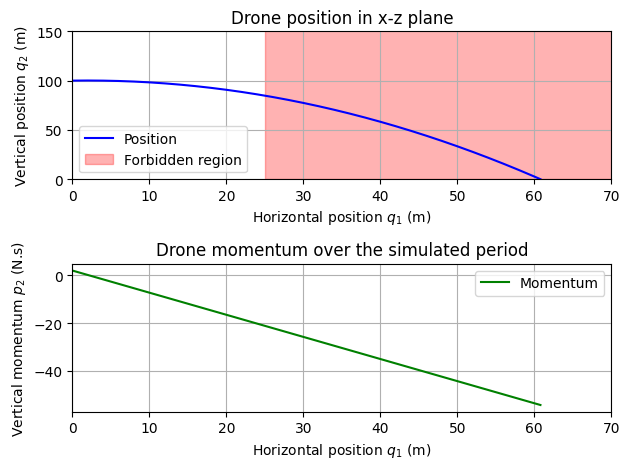

In [18]:
step = 0.05 #Time difference between values
Time = 8 #Length of simulation
initial_velocity = np.array([8, 1]) #From Question
initial_q = np.array([0,100]) # Initial position - from brief

initial_p = m * initial_velocity # Multiply velocity by m to get momentum
x0 = np.concatenate([initial_q, initial_p]) #Initial state value

u = np.array([0, 0]) #No control force - from question

T = np.arange(0, Time + step, step) #Creates a time vector
X = np.zeros((len(T), 4)) #Initiates a vector to store the state history
forbidden_zone_presence = np.zeros((len(T))) #1 will represent the drone in the forbidden zone at a given index and 0 will represent it not being there

X[0] = x0 #Adds the initial state to the state history vector
d = len(x0) #Dimension for identity matrix in backward-euler implementation

landed = False
i = 0 #Index to iterate over

M_mat = np.eye(d) - step * A # matrix used in backward euler for np.linalg.solve() function

while not landed and i < len(T)-1:
    i += 1 #skip first index as that is the intial condition

    # Implements backward euler as laid out in the text above
    b = X[i-1] + step * B @ (G_F + u)
    xi = np.linalg.solve(M_mat, b)

    # Forbidden zone is box for q = [25, 75] to q = [0,200]
    if xi[0] > 25 and xi[0] < 75 and xi[1] < 200: # Vertical lower bound not verified since the drone can't go below the ground level.
        forbidden_zone_presence[i] = 1
        if forbidden_zone_presence[i-1] == 0:
            print(f"The drone entered the forbidden zone after {T[i]:.2f}s.")
    elif forbidden_zone_presence[i-1] == 1:
        print(f"The drone left the forbidden zone at time t = {T[i]:.2f}s")
        
    #Checks for safe landing
    if xi[1] <= 0:
        landing_speed = np.linalg.norm(xi[2:]) / m
        if landing_speed > 10:
            print(f"Unsafe landing after {T[i]:.2f}s. The impact velocity was {landing_speed:.2f} m/s "
            f"which exceeds the maximum safe landing velocity of 10 m/s.")
        else:
            print(f"Safe landing after {T[i]:.2f}s. The impact velocity was {landing_speed:.2f} m/s "
            f"which is below the maximum safe velocity of 10 m/s.")
        X[i:] = np.array([xi[0], 0, 0, 0]) # Fix remaining states to 0, this sets the momentum to rest and ensures the drone stays above the ground
        landed = True
    else:
        X[i] = xi

# Display if the drone didnt land
if i == len(T)-1:
    print("The drone was unable to land within the simulation time.")
    
# Plotting the evolution of the state components
fig, axes = plt.subplots(2, 1)

# x-z position
axes[0].plot(X[:i, 0], X[:i, 1], color="blue", label='Position') # Plots trajectory
rect = plt.Rectangle((25, 0), 50, 200, color='red', alpha=0.3, label='Forbidden region') #Creates forbidden region with partial opacity
axes[0].add_patch(rect) #Plots forbidden region
axes[0].set_xlabel('Horizontal position $q_1$ (m)')
axes[0].set_xlim(0, 70)
axes[0].set_ylim(0, 150)
axes[0].set_ylabel('Vertical position $q_2$ (m)')
axes[0].set_title('Drone position in x-z plane')
axes[0].legend()
axes[0].grid(True)

#Momentum plot
axes[1].plot(X[:i,0], X[:i,3], color="green", label='Momentum') #Plots vertical momentum against horizontal position
axes[1].set_xlim(0, 70) # Same scale as trajectory so graphs line up for visual comparison
axes[1].set_xlabel('Horizontal position $q_1$ (m)')
axes[1].set_ylabel('Vertical momentum $p_2$ (N.s)')
axes[1].set_title('Drone momentum over the simulated period')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

The drone trajectory follows a parabolic path since gravity provides constant acceleration vertically downward. Vertical momentum decreases linearly throughout motion due to constant forces and therefore constant acceleration throughout. No horizontal forces mean that horizontal momentum is constant throughout (at 16 N.s). The drone enters the forbidden zone after 3.15 seconds and never exits it. The drone is demonstrated to land after 7.65s which is between 6s and 8s. The landing is unsafe with a total impact velocty of 28.45 $ms^{-1}$ which exceeds the safe landing velocity of 10 $ms^{-1}$.

### Question 3
A Kalman filter is used to estimate the full state (position and momentum) from noisy position-only measurements. It works by implementing both prediction steps, which propagates the estimate forward using the system dynamics, and, update steps, which adjust the prediction whenever a measurement is available.

Kalman Filter information, text copied from Sullivan, T.J (2026) 'Python Lecture/Lab 4', ES3J1: Advanced Systems and Software Engineering. University of Warwick : <br>

**Application to linear Kalman filtering.** Suppose that we have a sequence of evolving states $x_{i} \in \mathbb{R}^{n}$ given by
\begin{align}
    x_{i + 1} = F_{i} x_{i} + f_{i} + \eta_{i}
\end{align}
where $F_{i} \in \mathbb{R}^{n \times n}$ is a square matrix of the appropriate size, $f_{i} \in \mathbb{R}^{n}$ is a vector, and $\eta_{i} \sim N(0, Q_{i})$ is some $\mathbb{R}^{n}$-valued normally-distributed random noise independent of the state with covariance matrix $Q_{i} \in \mathbb{R}^{n \times n}$.  (Note that here we are using $i = 0, 1, 2, ...$ to index the *time steps* and not to index the entries of vectors or matrices!)  If we have a Gaussian state estimate $x_{i} \sim N(m_{i}, C_{i})$ at time step $i$, where $m_{i} \in \mathbb{R}^{n}$ and $C_{i} \in \mathbb{R}^{n \times n}$, then $x_{i + 1}$ is modelled as $N(\tilde{m}_{i + 1}, \tilde{C}_{i + 1})$, where the **forecast mean and covariance** are
\begin{align}
    \tilde{m}_{i + 1} & = F_{i} m_{i} + f_{i} , \\
    \tilde{C}_{i + 1} & = F_{i} C_{i} F_{i}^{\mathrm{T}} + Q_{i} .
\end{align}
Now suppose that we also make noisy observations $y_{i} \in \mathbb{R}^{m}$ according to
\begin{align}
    y_{i} = H_{i} x_{i} + \varepsilon_{i}
\end{align}
where $H_{i} \in \mathbb{R}^{m \times n}$ and $\varepsilon_{i} \sim N(0, R_{i})$ is some $\mathbb{R}^{m}$-valued normally-distributed random noise independent of the state with covariance matrix $R_{i} \in \mathbb{R}^{m \times m}$.  In this case we adjust the forecast mean and covariance to produce the following **analysis mean and covariance** for $x_{i + 1} \sim N(m_{i + 1}, C_{i + 1})$:
\begin{align}
    m_{i + 1} & = \tilde{m}_{i + 1} + \underbrace{ \tilde{C}_{i + 1} H_{i + 1}^{\mathrm{T}} \bigl( H_{i + 1} \tilde{C}_{i + 1} H_{i + 1}^{\mathrm{T}} + R_{i + 1} \bigr)^{-1} }_{\text{Kalman gain}} \underbrace{ \bigl( y_{i + 1} - H_{i + 1} \tilde{m}_{i + 1} \bigr) }_{\text{residual}} \\
    C_{i + 1} & = \tilde{C}_{i + 1} - \tilde{C}_{i + 1} H_{i + 1}^{\mathrm{T}} \bigl( H_{i + 1} \tilde{C}_{i + 1} H_{i + 1}^{\mathrm{T}} + R_{i + 1} \bigr)^{-1} H_{i + 1} \tilde{C}_{i + 1} .
\end{align}

All position measurements are taken at integer time values affected by gaussian noise, mean 0, SD 0.25. <br>
The state mean vector is initialised with $\hat{m} = 0$ and the covariance matrix with $\hat{C} = 10^8I_{4x4}$. This covariance matrix expresses little confidence in the earlier prediction; therefore, weighting the filter towards the measured values. As the simulation progresses, the matrix changes to increase the weighting toward the predicted values.

In [19]:
def kalman_filter(m_prev, c_prev, X, u, start_index, i, store_measured_values=False):

    '''
        Initial arguments:
        m_prev : previous filtered state variable
        c_prev : previous filtered covariance matrix
        X : History of true state variable, used for taking measurements and adding noise
        u : Control Force
        start_index : Index at start of current loop (used for establishing if time value is an integer)
        i : index of value within current loop

        Returns:
        m : filtered state values
        c : adjusted covariance matrix
    '''
    #Constant throughout the assignment, defined in function
    mean = 0
    SD = 0.25
    
    f = F @ (step * B @ (G_F + u))
    
    #predictions
    m_pred = F @ m_prev + f
    C_pred = F @ c_prev @ F.T + Q #Takes the C value at the prior integer time point
    
    # Include measured value for integer time intervals
    if (start_index + i) % int(1/step) == 0:
        y1 = X[i][:2] + np.random.normal(mean, SD, size=2) # Noisy observation of position
        if store_measured_values:
            y[int(i * step)] = y1 
        residual = y1 - H @ m_pred
        Kalman_gain = C_pred @ H.T @ np.linalg.inv(H @ C_pred @ H.T + R)  # Kalman gain

        # Update the predicted states with measured values
        m = m_pred + Kalman_gain @ residual
        c = C_pred - Kalman_gain @ H @ C_pred
    else:
        # If no measurement store predicted values
        m = m_pred
        c = C_pred
    return m, c
    

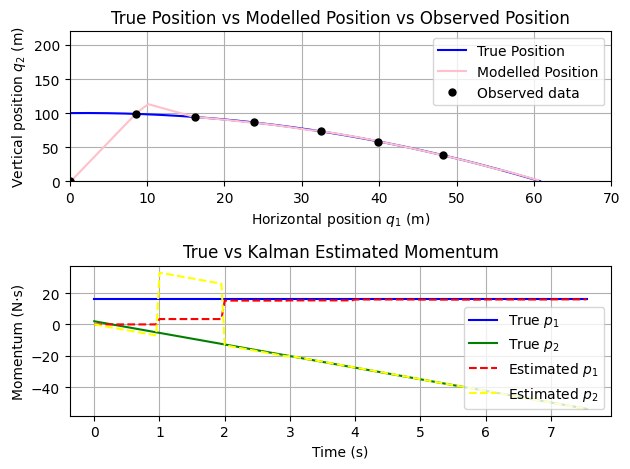

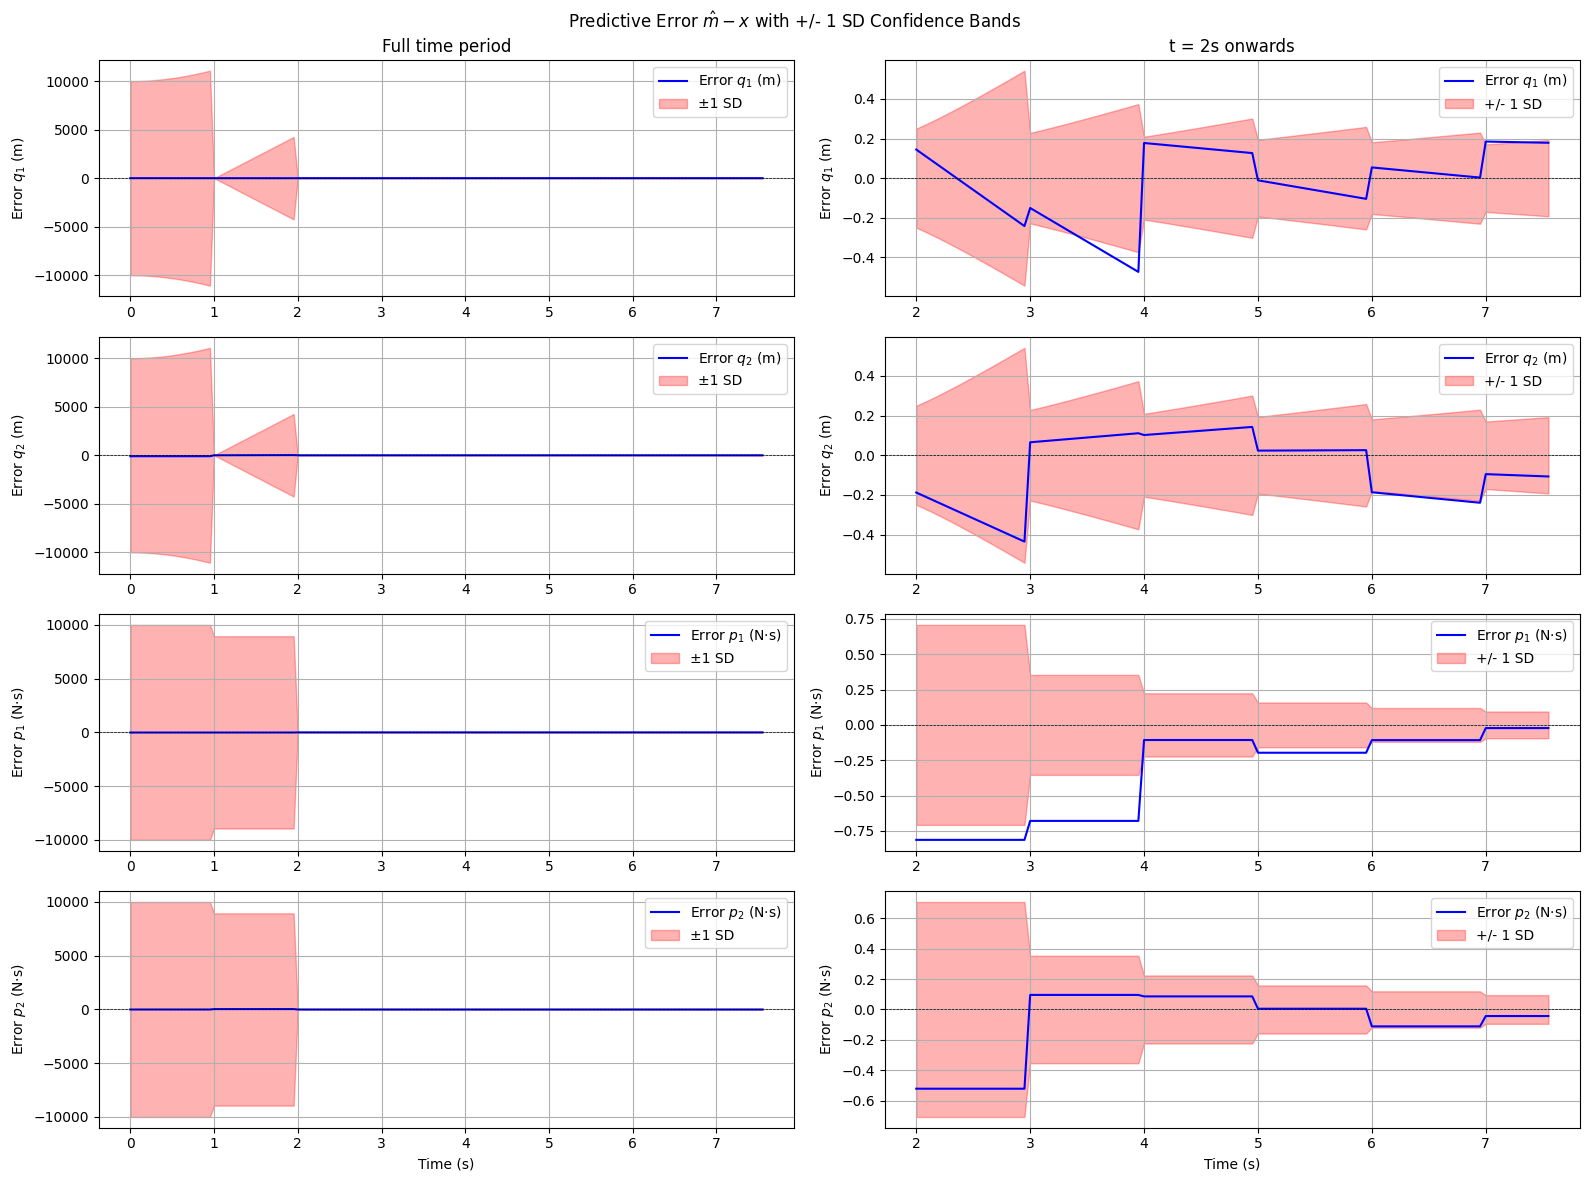

In [20]:
H = np.array([[1, 0, 0, 0],
              [0, 1, 0, 0]]) # Observation matrix
Q = np.zeros((4, 4)) # no random motion to drone
R = (0.25**2)*np.eye(2,2) # 0.25m standard deviation measurement error in each direction independently
F = np.linalg.inv(np.eye(4) - step * A) # Defined outside of the loop as doesnt change between increments

# Initial values
m0 = np.zeros(4)
C0 = 1e8 * np.eye(4)

# Initiate matrices to store state and covariance history
M = np.zeros(np.shape(X))
C = np.zeros((len(T), 4, 4))

# Add initial values to matrices
C[0] = C0 
M[0] = m0

#Global y to store noise readings
y = np.zeros((Time+1, 2))

i2 = 0 # Index for question 3
# Iterates over each time value and implements the kalman filter
while (M[i2][1] > 0 or i2 < (1/step)) and i2 < len(T)-1:
    i2 += 1
    M[i2], C[i2] = kalman_filter(M[i2-1], C[i2-1], X, np.array([0, 0]), 0, i2, True)

M[i2] = np.array([0, 0, 0, 0])
C[i2] = np.zeros((4, 4)) # stops the state and covariance history to just before the drone hits the ground

# Plots the filtered states against the true states
fig, axes = plt.subplots(2, 1) 
axes[0].plot(X[:i, 0], X[:i, 1], color="blue", label='True Position')
axes[0].plot(M[:i2, 0], M[:i2, 1], color="pink", label='Modelled Position')
axes[0].set_xlabel('Horizontal position $q_1$ (m)')
axes[0].plot(y[:int(i2 * step), 0], y[:int(i2 * step), 1], 'k.', markersize=10, label='Observed data')
axes[0].set_xlim(0, 70)
axes[0].set_ylim(0, 220)
axes[0].set_ylabel('Vertical position $q_2$ (m)')
axes[0].set_title('True Position vs Modelled Position vs Observed Position')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(T[:i2], X[:i2, 2], color="blue", label='True $p_1$', linestyle='-')
axes[1].plot(T[:i2], X[:i2, 3], color="green", label='True $p_2$', linestyle='-')
axes[1].plot(T[:i2], M[:i2, 2], color="red", label='Estimated $p_1$', linestyle='--')
axes[1].plot(T[:i2], M[:i2, 3], color="yellow", label='Estimated $p_2$', linestyle='--')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Momentum (N·s)')
axes[1].set_title('True vs Kalman Estimated Momentum')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 2, figsize=(16, 12))
labels = ['$q_1$ (m)', '$q_2$ (m)', '$p_1$ (N·s)', '$p_2$ (N·s)']

for j in range(4):
    error = M[:i2, j] - X[:i2, j]
    sd = np.sqrt(C[:i2, j, j])

    # Plots error and standard deviation bars for entire simulation length
    axes[j, 0].plot(T[:i2], error, color='blue', label=f'Error {labels[j]}')
    axes[j, 0].fill_between(T[:i2], -sd, sd, alpha=0.3, color='red', label='±1 SD')
    axes[j, 0].axhline(0, color='black', linestyle='--', linewidth=0.5) # Centreline
    axes[j, 0].set_ylabel(f'Error {labels[j]}')
    axes[j, 0].legend()
    axes[j, 0].grid(True)

    # Plots error and standard deviation bars for t = 2s to the end of the simulation
    axes[j, 1].plot(T[int(2 / step):i2], error[int(2 / step):], color='blue', label=f'Error {labels[j]}')
    axes[j, 1].fill_between(T[int(2 / step):i2], -sd[int(2 / step):], sd[int(2 / step):], alpha=0.3, color='red', label='+/- 1 SD')
    axes[j, 1].axhline(0, color='black', linestyle='--', linewidth=0.5) # Centreline
    axes[j, 1].set_ylabel(f'Error {labels[j]}')
    axes[j, 1].legend()
    axes[j, 1].grid(True)
axes[3, 0].set_xlabel('Time (s)')
axes[3, 1].set_xlabel('Time (s)')
axes[0, 0].set_title('Full time period')
axes[0, 1].set_title('t = 2s onwards')
fig.suptitle('Predictive Error $\\hat{m} - x$ with +/- 1 SD Confidence Bands')
plt.tight_layout()
plt.show()

For the first 2 seconds, the standard deviation bands are very large, this is due to the large initial covariance matrix of $C = 10^8I$ which represents a significant lack of confidence in the predictive value. The standard deviation bands are several orders of magnitude wider than the actual error for the first 2 seconds and then reduce to give a reasonable estimate of the predictive error as shown in the plots for t = 2s onwards. The predicitve error remains wthin the $\pm$ 1 SD bands after convergence, this shows the filter is well calibrated. The predictive error drops over the simulation for all the plots although stays in the region of $\pm$ 0.25 from the centreline, along with the standard deviation. This is to be expected due to the gaussian noise applied to the measurement values which had a mean of 0 and a standard deviation of 0.25.

## Question 4

G + u = K(x - x*) where K is the matrix of controller values

$h_{safe}$ at 10m, this is below the earlier defined maximum safe height of 13.6 m but still high enough that an overshoot risks hitting the ground.

Controller values kp, kd as well as the final waypoint height were defined using iterative for loops to find optimum values for smooth flight and simulation time. Waypoint values were chosen to guide the drone around the forbidden zone with a reasonable amount of clearance.

The control force is computed from the Kalman estimate ,m, of the state variable in each iteration as opposed to the true state x. This satisfies the requirement that the feedback rule has no knowledge of the true state. The true state is tracked throughout in order for noisy measurements to be taken and for visual comparison between the measured and true trajectories.

In [21]:
def go_to_position(start, Mstart, end, start_index, c0):
    '''
        initial arguments:
        start : True initial state
        Mstart : Filtered initial state
        end : Target position
        start_index : Global index position at the start of the function call
        c0 : Covariance matrix at start of function call

        returns:
        trajectory : History of true trajectory
        M : History of filtered trajectory
        i+start_index : Global index at end of function
        C : History of covariance values
    '''

    # Sets up arrays to record values throughout function
    trajectory = np.array([start])
    M = np.array([Mstart])
    C = np.array([c0])
    i = 0  

    while start_index+i < len(Q4_T):
        i += 1
        u = K @ (M[i-1] - end) - G_F # Control force 
        
        if np.linalg.norm(u) > 15: # Euclidian magnitude can't exceed 15N
            u = 15 * u / np.linalg.norm(u) # Not met gravity before clamping as PD can catch and correct the velocity

        #Works out the true trajectory as in question 1
        b = trajectory[i-1] + step * B @ (G_F + u)
        xi = np.linalg.solve(M_mat, b)
        trajectory = np.vstack([trajectory, xi])

        # Works out the filtered states
        m, c = kalman_filter(M[i-1], C[i-1], trajectory, u, start_index, i)

        # Tracks the filtered states and records the covariance matrices
        M = np.vstack([M, m])
        C = np.vstack([C, c.reshape(1, 4, 4)])

        # Error margin of 1m, ensures velocity magnitude is also below 1 m/s
        if np.linalg.norm(m[:2] - end[:2]) < 1 and np.linalg.norm(m[2:]) < 1:

            tx, ty = end[:2] # Unpacks for printing without brackets
            print(f"Reached target ({tx}, {ty}), after {(i+start_index)*step :.2f} seconds.")
            return trajectory[1:], M[1:], i+start_index, C[1:]

    # If time limit reach before reaching target print message
    print(f"Warning: target ({end}) not reached, simulation time exceeded")
    return trajectory[1:], M[1:], i + start_index, C[1:]
    
def hover_and_fall(start, Mstart, Hover_height, start_index, c):
    '''
        initial arguments:
        start : True initial state
        Mstart : Filtered initial state
        start_index : Global index position at the start of the function call
        c : Covariance matrix at start of function call
        

        returns:
        trajectory : History of true trajectory
        M : History of filtered trajectory
        i+start_index : Global index at end of function
        C : History of covariance values
    '''
    trajectory = np.array([start])
    M = np.array([Mstart])
    C = np.array([c])
    i = 0
  
    while trajectory[i, 1] >= 0:
        i += 1
        if i >= 5/step:
            u = np.array([0, 0]) # No control force while falling

            # Records true trajectory
            b = trajectory[i-1] + step * B @ (G_F + u)    
            xi = np.linalg.solve(M_mat, b)
            trajectory = np.vstack([trajectory, xi])

            # records filtered trajectory
            m, c = kalman_filter(M[i-1], C[i-1], trajectory, u, start_index, i)        
            M = np.vstack([M, m])
            C = np.vstack([C, c.reshape(1, 4, 4)])

            # Identifies if the drone has landed
            if m[1] <= 0:
                print(f"Successfully landed after {(start_index + i) * step :.2f} seconds with a true velocity of {np.linalg.norm(trajectory[i][2:]) / 2 :.2f} m/s.")
                return trajectory[1:], M[1:], i+start_index, C[1:]
        else:
            # Finds control force to retain hover
            u = K @ (M[i-1] - Hover_height) - G_F 
            
            if np.linalg.norm(u) > 15:
                u = 15 * u / np.linalg.norm(u) # Shouldn't be needed as just aiming to meet gravity

            # Records the true trajectory
            b = trajectory[i-1] + step * B @ (G_F + u)
            xi = np.linalg.solve(M_mat, b)
            trajectory = np.vstack([trajectory, xi])
           

            # Records the filtered trajectory
            m, c = kalman_filter(M[i-1], C[i-1], trajectory, u, start_index, i)
            M = np.vstack([M, m])
            C = np.vstack([C, c.reshape(1, 4, 4)])

        # Identifies if simulation reaches time limit
        if i > len(Q4_T)-start_index:
            print(f"Warning: ground not reached, simulation time exceeded")
            return trajectory[1:], M[1:], i+start_index, C[1:]
    return trajectory[1:], M[1:], i+start_index, C[1:]

Reached target (20, 210), after 21.90 seconds.
Reached target (80, 210), after 38.10 seconds.
Reached target (100, 70), after 50.30 seconds.
Reached target (100, 10), after 66.30 seconds.
Successfully landed after 73.60 seconds with a true velocity of 8.78 m/s.


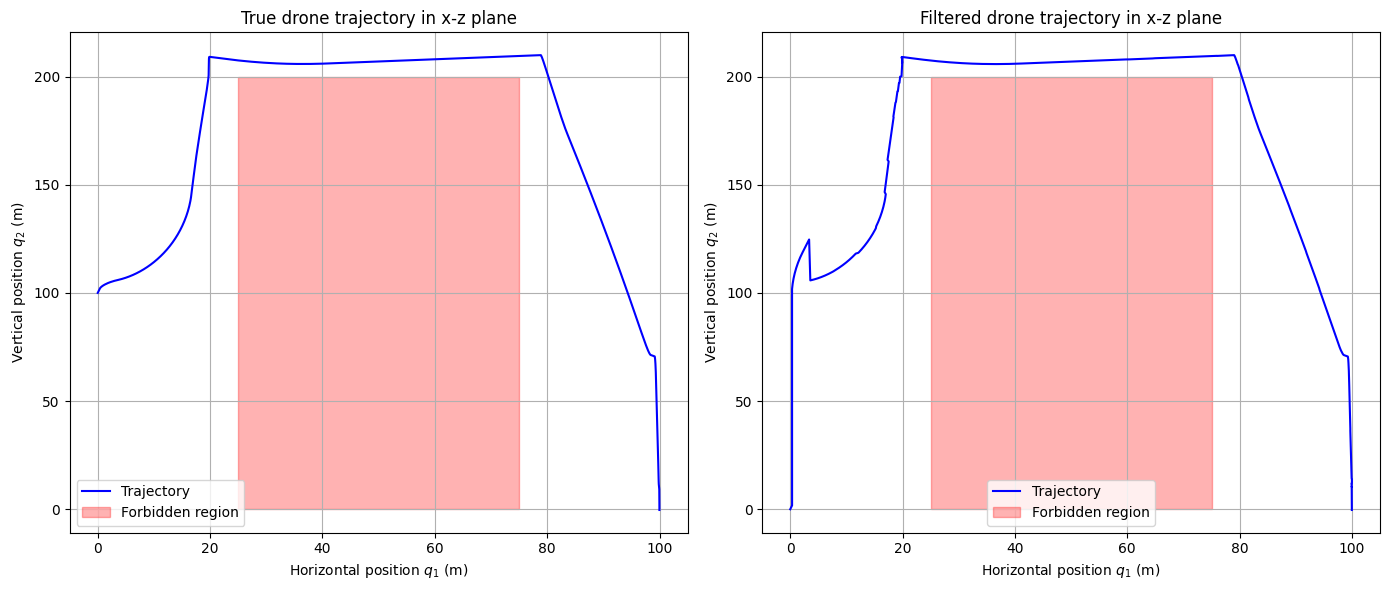

In [22]:
Q4_Time = 90 # Simulation time
step = 0.05 # Step value unchanged through assignment

Q4_T = np.arange(0, Q4_Time + step, step) # Time vector

# Controller values and final waypoint height - experimentally derived
kp = -17
kd = -32
wp3_height = 70
K = np.array([[kp, 0, kd, 0], [0, kp, 0, kd]])

# Initial conditions
c0 = 1e8 * np.eye(4)
m0 = np.array([0, 0, 0, 0])

# Kalman filter parameter
F = np.linalg.inv(np.eye(4) - step * A)

# Defines initial and waypoint positions
Initial_position = np.array([0, 100, 0, 0])
Waypoint_1 = np.array([20, 210, 0, 0])
Waypoint_2 = np.array([80, 210, 0, 0])
Waypoint_3 = np.array([100, wp3_height, 0, 0]) # This will allow the drone to slow before approaching the final safe hover height
Hover_height = np.array([100, 10, 0, 0])
positions = np.array([Initial_position, Waypoint_1, Waypoint_2, Waypoint_3, Hover_height])

# Adds initial values to arrays tracking covariance, position and filtered position to matrices
Q4_X = np.array([Initial_position])
Q4_M = np.array([m0])
Q4_C = np.array([c0])

index = 0 # Global index value recording index of current time stamp
waypoint_number = 0 # Index of current waypoint target
while waypoint_number < 4 and index < len(Q4_T):
    waypoint_number += 1

    #Runs function to move to the following waypoint
    X_temp, M_temp, index, C_temp = go_to_position(Q4_X[-1], Q4_M[-1], positions[waypoint_number], index, Q4_C[-1]) 
    # Updates large history tracking matrices
    Q4_X = np.vstack([Q4_X, X_temp])
    Q4_M = np.vstack([Q4_M, M_temp])
    Q4_C = np.concatenate([Q4_C, C_temp], axis=0)  # 3D stacking along axis 0

if index < len(Q4_T):
    # Runs function to get the drone to hover for 5 seconds before falling
    X_temp, M_temp, index, C_temp = hover_and_fall(Q4_X[-1], Q4_M[-1], Hover_height, index, Q4_C[-1])

    # Updates large history tracking matrices
    Q4_X = np.vstack([Q4_X, X_temp])
    Q4_M = np.vstack([Q4_M, M_temp])
    Q4_C = np.concatenate([Q4_C, C_temp], axis=0)  # 3D stacking along axis 0

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(Q4_X[:, 0], Q4_X[:, 1], 'b-', label='Trajectory')
rect = plt.Rectangle((25, 0), 50, 200, color='red', alpha=0.3, label='Forbidden region')
axes[0].add_patch(rect)
axes[0].set_xlabel('Horizontal position $q_1$ (m)')
axes[0].set_ylabel('Vertical position $q_2$ (m)')
axes[0].set_title('True drone trajectory in x-z plane')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(Q4_M[:, 0], Q4_M[:, 1], 'b-', label='Trajectory')
rect2 = plt.Rectangle((25, 0), 50, 200, color='red', alpha=0.3, label='Forbidden region')
axes[1].add_patch(rect2)
axes[1].set_xlabel('Horizontal position $q_1$ (m)')
axes[1].set_ylabel('Vertical position $q_2$ (m)')
axes[1].set_title('Filtered drone trajectory in x-z plane')
axes[1].legend()
axes[1].grid(True)
plt.tight_layout()
plt.show()